# Optimization Using Gradients — Analytical Method (Linear Regression)

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the **analytical method**
for optimization with gradients (Week 2 — Gradients and Gradient Descent).

This notebook works the **2D power-line problem**, which turns out to be exactly
**linear regression**:

- three power lines, a straight fiber line $y = Mx + B$, vertical connecting wires
- cost = sum of **squared** wire lengths (the *squared loss*)
- derive the cost function $E(M,B) = 14M^2 + 3B^2 + 38 + 12MB - 42M - 20B$
- minimize it by setting $\nabla E = 0$ and solving the system
- get the optimal line $M = \tfrac12,\; B = \tfrac73$, with minimum cost $E = 4.167$
- connect to linear regression / least squares, with a SymPy and NumPy cross-check

This notebook follows the repository `GUIDELINES.md` template and continues directly
from *Optimization with Gradients: An Example*.

## 1. Introduction

> *"This example introduces one of the most important machine-learning models out there,
> called linear regression."*

In Week 1 the **power-line problem** was one-dimensional: place a house to connect to
power lines at least cost. Now it is **two-dimensional** — we choose a whole **line**, and
the cost is the sum of squared connection distances.

Choosing the line means choosing its slope $M$ and intercept $B$, so we are minimizing a
**function of two variables** $E(M, B)$ — exactly the setting for the gradient.

After this notebook you will be able to:

- set up a least-squares cost function from data
- minimize it analytically via $\nabla E = 0$
- recognize this as linear regression and verify it with NumPy

## 2. The setup

The three power lines sit at

$$
(1, 2), \qquad (2, 5), \qquad (3, 3).
$$

We want a fiber line $y = Mx + B$. Each power line connects to it with a wire **parallel
to the $y$-axis** (a vertical segment). The cost of a connection is the **square of the
wire length** — and the total cost is the sum.

### Where does power line $x=1$ connect?

At $x=1$ the fiber line is at height $M(1) + B = M + B$. The power line is at height $2$,
so the wire length is $|M + B - 2|$ and its cost is $(M + B - 2)^2$.

Doing the same for all three:

$$
\text{cost} = \underbrace{(M+B-2)^2}_{(1,2)} + \underbrace{(2M+B-5)^2}_{(2,5)} + \underbrace{(3M+B-3)^2}_{(3,3)} .
$$

## 3. Deriving the cost function $E(M,B)$

Expanding each square and collecting like terms:

$$
E(M,B) = 14M^2 + 3B^2 + 38 + 12MB - 42M - 20B .
$$

Let's confirm that expansion with SymPy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

M, B = sp.symbols('M B')

points = [(1, 2), (2, 5), (3, 3)]
E = sum((M*px + B - py)**2 for (px, py) in points)

print("E(M, B) expanded =", sp.expand(E))

E(M, B) expanded = 3*B**2 + 12*B*M - 20*B + 14*M**2 - 42*M + 38


## 4. The partial derivatives

> *"All we have to do is calculate the two partial derivatives $\partial E/\partial M$ and
> $\partial E/\partial B$, set them both equal to zero, and solve for $M$ and $B$."*

$$
\frac{\partial E}{\partial M} = 28M + 12B - 42
$$

$$
\frac{\partial E}{\partial B} = 12M + 6B - 20
$$

In [2]:
EM = sp.diff(E, M)
EB = sp.diff(E, B)
print("∂E/∂M =", sp.expand(EM))   # 28M + 12B - 42
print("∂E/∂B =", sp.expand(EB))   # 12M + 6B - 20

∂E/∂M = 12*B + 28*M - 42
∂E/∂B = 6*B + 12*M - 20


## 5. Solving the system $\nabla E = 0$

Set both partials to zero:

$$
\begin{cases} 28M + 12B - 42 = 0 \\ 12M + 6B - 20 = 0 \end{cases}
$$

**By hand (as in the lecture):** multiply the second equation by $2$ →
$24M + 12B - 40 = 0$. Subtract it from the first:

$$
(28M + 12B - 42) - (24M + 12B - 40) = 4M - 2 = 0 \;\Rightarrow\; M = \tfrac12 .
$$

Plug $M = \tfrac12$ into the second equation:

$$
12(\tfrac12) + 6B - 20 = 6 + 6B - 20 = 6B - 14 = 0 \;\Rightarrow\; B = \tfrac{14}{6} = \tfrac{7}{3}.
$$

In [3]:
solution = sp.solve([EM, EB], [M, B], dict=True)[0]
print("Optimal parameters:", solution)

E_min = E.subs(solution)
print("Minimum cost E =", E_min, "=", float(E_min))

Optimal parameters: {B: 7/3, M: 1/2}
Minimum cost E = 25/6 = 4.166666666666667


## 6. The fitted line and the squared losses

The optimal line is

$$
y = \tfrac12 x + \tfrac73 .
$$

Below we plot the three power lines, the fitted fiber line, and the **squares** whose
total area is the cost we minimized.

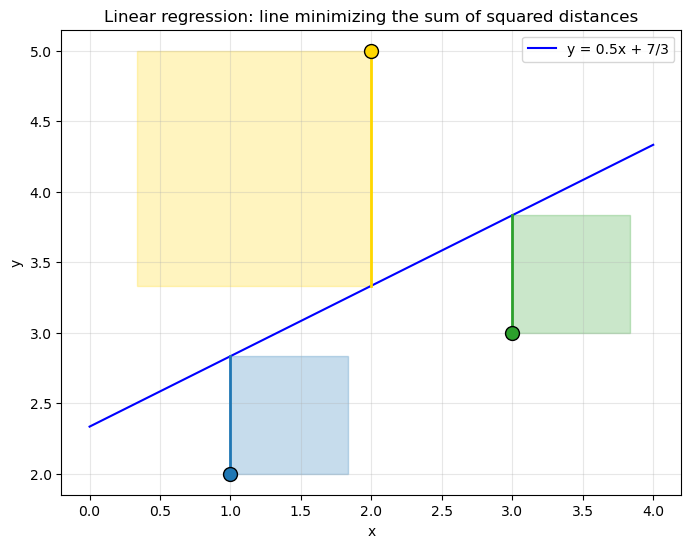

In [4]:
m_opt, b_opt = 0.5, 7/3
pts = np.array([(1, 2), (2, 5), (3, 3)], dtype=float)

xx = np.linspace(0, 4, 100)
yy = m_opt * xx + b_opt

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(xx, yy, "b-", label=f"y = {m_opt}x + 7/3")

colors = ["tab:blue", "gold", "tab:green"]
for (px, py), c in zip(pts, colors):
    fit_y = m_opt * px + b_opt
    # vertical wire
    ax.plot([px, px], [py, fit_y], color=c, linewidth=2)
    # the squared-loss square (side = |residual|), drawn to the right of the wire
    side = fit_y - py
    ax.add_patch(plt.Rectangle((px, py), side, side, alpha=0.25, color=c))
    ax.plot(px, py, "o", color=c, markersize=10, markeredgecolor="black")

ax.set_title("Linear regression: line minimizing the sum of squared distances")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 7. The cost surface $E(M, B)$

$E$ is a bowl in $(M, B)$ space; its lowest point is the solution we found.

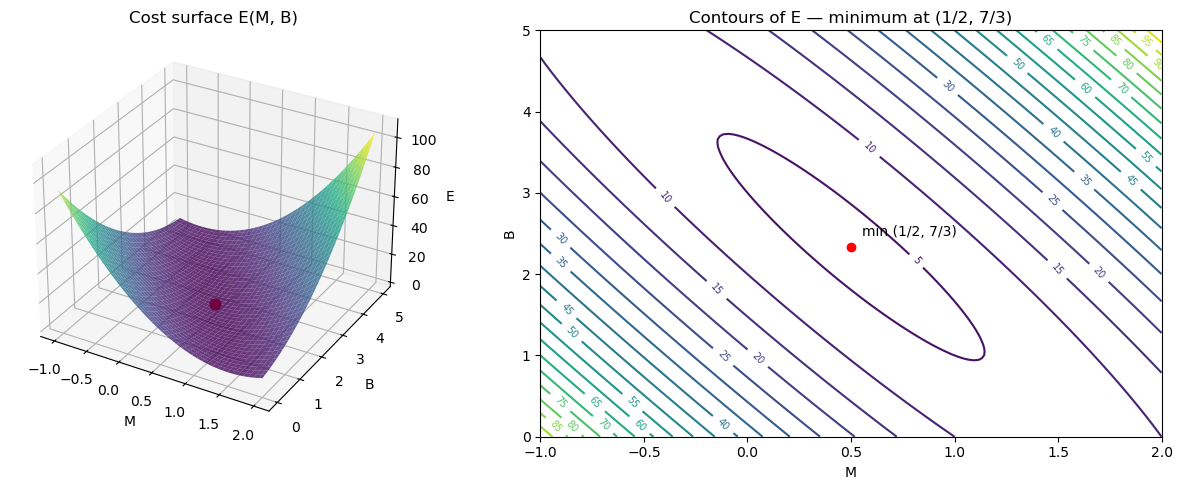

In [5]:
def E_num(m, b):
    return 14*m**2 + 3*b**2 + 38 + 12*m*b - 42*m - 20*b

mm = np.linspace(-1, 2, 120)
bb = np.linspace(0, 5, 120)
MM, BB = np.meshgrid(mm, bb)
ZZ = E_num(MM, BB)

fig = plt.figure(figsize=(13, 5))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(MM, BB, ZZ, cmap="viridis", alpha=0.8)
ax.scatter([0.5], [7/3], [E_num(0.5, 7/3)], color="red", s=60)
ax.set_title("Cost surface E(M, B)")
ax.set_xlabel("M"); ax.set_ylabel("B"); ax.set_zlabel("E")

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contour(MM, BB, ZZ, levels=20, cmap="viridis")
ax2.clabel(cs, inline=True, fontsize=7)
ax2.plot(0.5, 7/3, "ro")
ax2.annotate("min (1/2, 7/3)", (0.5, 7/3), textcoords="offset points", xytext=(8, 8))
ax2.set_title("Contours of E — minimum at (1/2, 7/3)")
ax2.set_xlabel("M"); ax2.set_ylabel("B")
plt.tight_layout()
plt.show()

## 8. This is linear regression — cross-check with NumPy

> *"This problem is actually called linear regression... you have a bunch of points and
> you try to find the closest line to them."*

The analytical solution we derived is exactly what `numpy.polyfit` (ordinary least
squares) returns.

In [6]:
x_data = np.array([1, 2, 3], dtype=float)
y_data = np.array([2, 5, 3], dtype=float)

m_fit, b_fit = np.polyfit(x_data, y_data, 1)
print(f"NumPy least squares:  M = {m_fit:.6f},  B = {b_fit:.6f}")
print(f"Our analytical answer: M = {0.5:.6f},  B = {7/3:.6f}")

NumPy least squares:  M = 0.500000,  B = 2.333333
Our analytical answer: M = 0.500000,  B = 2.333333


## 9. Why we will need gradient descent

> *"When we solve this equation of two variables and two unknowns, that can be pretty
> hard, especially if you have many variables. Solving an $m \times n$ system can be
> expensive. Is there a faster way? Yes — gradient descent."*

The analytical method is exact, but solving $\nabla E = 0$ in closed form becomes
costly (or impossible) for large problems. The next lectures introduce **gradient
descent**, an iterative method that minimizes functions efficiently.

## 10. Exercises

### Basic
1. Write the squared-loss cost contributed by a power line at $(x_i, y_i)$ for the line
   $y = Mx + B$.
2. State the two equations you solve to minimize $E(M, B)$.

### Intermediate
3. Re-derive $\partial E/\partial M$ and $\partial E/\partial B$ for the three given points.
4. Verify by substitution that $(M, B) = (\tfrac12, \tfrac73)$ makes both partials zero.

### Advanced
5. Fit a line to the points $(0,1), (1,3), (2,2), (3,5)$ by minimizing the squared loss
   analytically (set up $E$, solve $\nabla E = 0$). Check against `np.polyfit`.
6. Explain why $E(M,B)$ is guaranteed to have a single minimum (hint: what kind of
   function of $M$ and $B$ is a sum of squares?).

## 11. Solutions / Checks

In [7]:
M, B = sp.symbols('M B')

def fit_least_squares(points):
    E = sum((M*px + B - py)**2 for (px, py) in points)
    sol = sp.solve([sp.diff(E, M), sp.diff(E, B)], [M, B], dict=True)[0]
    return E, sol

# 3 & 4
E, sol = fit_least_squares([(1, 2), (2, 5), (3, 3)])
print("3. ∂E/∂M =", sp.expand(sp.diff(E, M)), ", ∂E/∂B =", sp.expand(sp.diff(E, B)))
print("4. solution:", sol,
      "| ∂E/∂M there =", sp.diff(E, M).subs(sol),
      ", ∂E/∂B there =", sp.diff(E, B).subs(sol))

# 5
pts5 = [(0, 1), (1, 3), (2, 2), (3, 5)]
_, sol5 = fit_least_squares(pts5)
xa = np.array([p[0] for p in pts5], float); ya = np.array([p[1] for p in pts5], float)
print("5. analytical:", sol5, " | numpy:", tuple(np.round(np.polyfit(xa, ya, 1), 6)))

print("6. A sum of squares is a convex (upward) paraboloid in (M, B), "
      "so it has exactly one minimum.")

3. ∂E/∂M = 12*B + 28*M - 42 , ∂E/∂B = 6*B + 12*M - 20
4. solution: {B: 7/3, M: 1/2} | ∂E/∂M there = 0 , ∂E/∂B there = 0
5. analytical: {B: 11/10, M: 11/10}  | numpy: (1.1, 1.1)
6. A sum of squares is a convex (upward) paraboloid in (M, B), so it has exactly one minimum.


## 12. Conclusion

- The 2D power-line problem is **linear regression**: fit $y = Mx + B$ by minimizing the
  **sum of squared** vertical distances.
- The cost is a function of two variables, $E(M,B) = 14M^2 + 3B^2 + 38 + 12MB - 42M - 20B$.
- Minimize it the usual way: set $\nabla E = 0$ and solve, giving
  $M = \tfrac12,\; B = \tfrac73$ and minimum cost $E = 4.167$.
- This matches `np.polyfit` exactly — it *is* ordinary least squares.
- Solving the system analytically is exact but expensive at scale, which motivates
  **gradient descent** in the following lectures.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/test.mp4`), which is the Coursera *Calculus for Machine Learning and Data
Science* (Week 2) lecture on the **analytical method** for optimization with gradients
(the 2D power-line / linear-regression example). Key spoken points, lightly cleaned:

> The 2D power-line problem: three power lines at $(1,2),(2,5),(3,3)$; find the line
> $y=Mx+B$ minimizing the sum of squared vertical connection costs. Power line $x=1$
> connects at height $M+B$, giving cost $(M+B-2)^2$; similarly $(2M+B-5)^2$ and
> $(3M+B-3)^2$. Expanding and combining gives $E(M,B)=14M^2+3B^2+38+12MB-42M-20B$. The
> partial derivatives are $\partial E/\partial M=28M+12B-42$ and $\partial E/\partial
> B=12M+6B-20$. Setting both to zero and solving (multiply the second by 2 and subtract)
> gives $M=1/2$ and $B=7/3$, with minimum cost $E=4.167$. This is linear regression — the
> closest line to a set of points. Solving such systems is expensive for many variables,
> which motivates gradient descent (next videos).